# 02 — EDA : Analyse Exploratoire des Données
## FAERS Drug Hospitalization Dataset

**Module :** Machine Learning — Phase 1  
**Auteurs :** Amine El Biyadi / Aya Raissouni / Douae Moeniss  
**Date :** Mai 2026  
**Encadrant :** Pr. Y. EL YOUNOUSSI  

---

**Objectif :** Mener une analyse exploratoire complète du dataset FAERS constitué en Phase 1,  
identifier les variables prédictives, analyser le déséquilibre des classes,  
et produire une bonne synthèse.

**Livrables couverts :**
- Exploration univariée (histogramme, boxplot, stats descriptives, modalités rares)
- Exploration bivariée (numérique x cible, catégorielle x cible, numérique x numérique)
- Analyse spécifique du déséquilibre (ratio exact, stats séparées, features signaux)
- Synthèse finale


## 1. Imports et chargement du dataset

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

PALETTE    = ["#5A81C0", "#E298AE"]
PALETTE_CAT = sns.color_palette("deep", 12)

# ── Dataset path — adjust if needed
DATASET_PATH = "../data/dataset.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}\n"
        "Lancez d'abord : python src/data_collection.py"
    )

df = pd.read_csv(DATASET_PATH)

NUMERIC_COLS = [
    "patient_age", "nb_drugs", "nb_reactions",
    "worst_reaction_outcome", "nb_suspect_drugs",
]
CATEGORICAL_COLS = [
    "patient_sex", "reporter_qualification", "route_of_admin",
    "country", "has_black_box_warning", "is_concomitant_present",
]
TARGET_COL = "seriousnesshospitalization"

# Cast target to int for computations, keep original for display
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)

print(f"Dataset chargé — {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


Dataset chargé — 10,200 lignes x 12 colonnes
pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


---
## 2. Exploration univariée

### 2a. Variables numériques — Statistiques descriptives


In [16]:
desc = df[NUMERIC_COLS].describe().round(2)
desc.loc["median"]   = df[NUMERIC_COLS].median().round(2)
desc.loc["skewness"] = df[NUMERIC_COLS].skew().round(2)
desc


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs
count,6775.00,10200.00,10200.00,9538.00,10200.00
mean,81.39,3.23,2.67,4.91,1.72
std,753.78,3.86,3.13,1.77,1.54
min,0.00,1.00,1.00,1.00,1.00
25%,47.00,1.00,1.00,3.00,1.00
50%,61.00,2.00,2.00,6.00,1.00
75%,72.00,4.00,3.00,6.00,2.00
max,32193.00,88.00,60.00,6.00,32.00
median,61.00,2.00,2.00,6.00,1.00
skewness,32.85,4.59,5.93,-1.26,6.36


### 2b. Variables numériques — Histogrammes et Boxplots

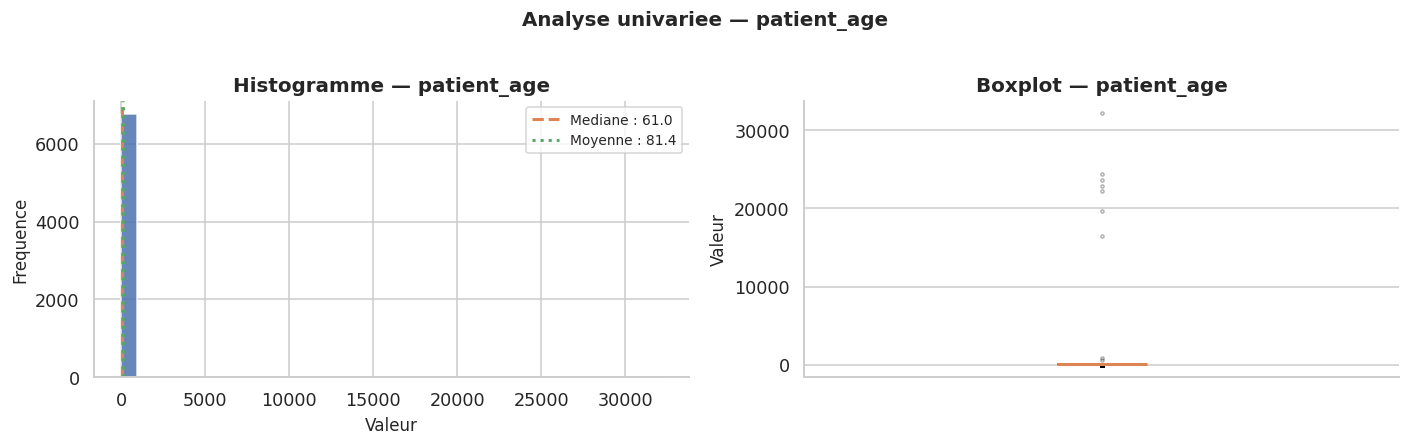

  n=6,775 | manquants=3425 | min=0.0 | max=32193.0 | skewness=32.85



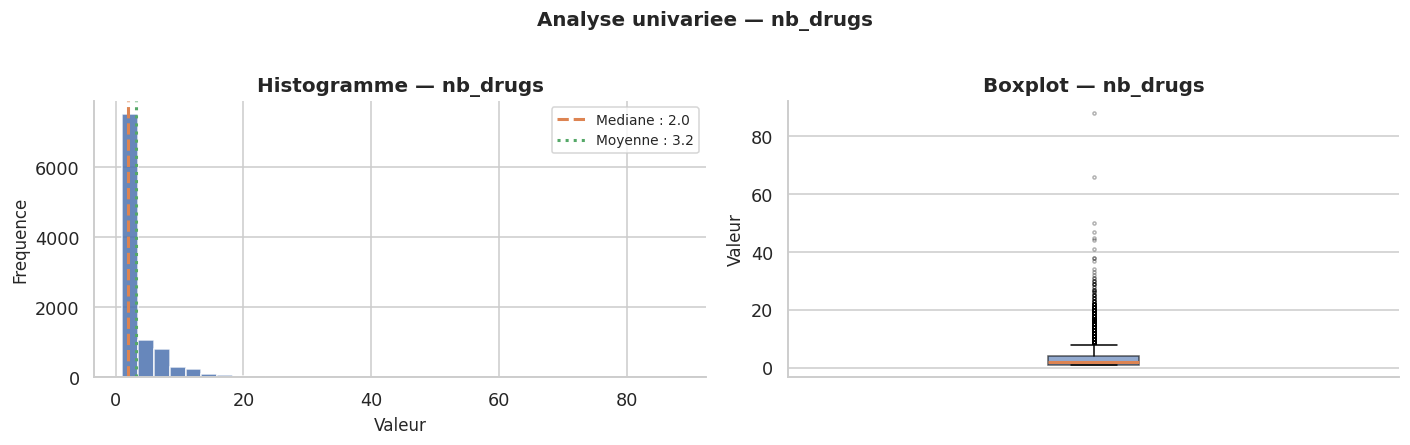

  n=10,200 | manquants=0 | min=1.0 | max=88.0 | skewness=4.59



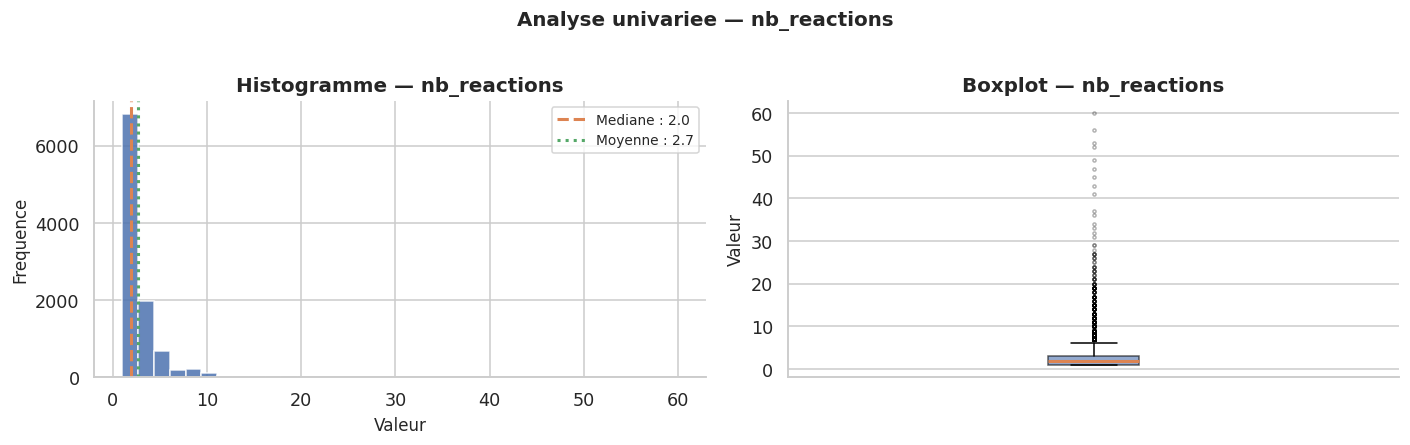

  n=10,200 | manquants=0 | min=1.0 | max=60.0 | skewness=5.93



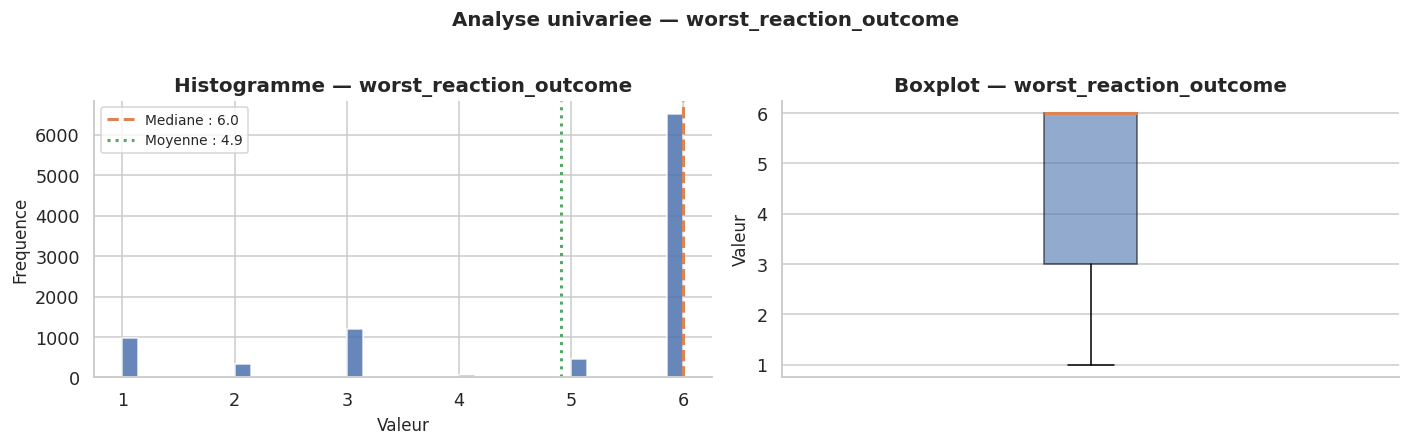

  n=9,538 | manquants=662 | min=1.0 | max=6.0 | skewness=-1.26



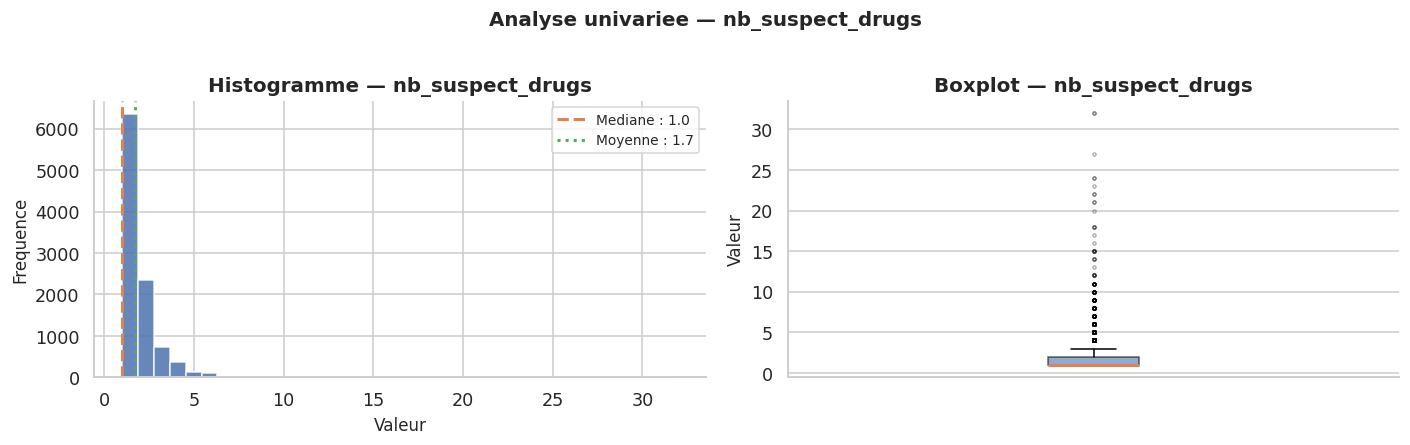

  n=10,200 | manquants=0 | min=1.0 | max=32.0 | skewness=6.36



In [17]:
for col in NUMERIC_COLS:
    data = df[col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.hist(data, bins=35, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="#DD8452", linestyle="--", linewidth=2,
               label=f"Mediane : {data.median():.1f}")
    ax.axvline(data.mean(), color="#55A868", linestyle=":", linewidth=2,
               label=f"Moyenne : {data.mean():.1f}")
    ax.set_title(f"Histogramme — {col}")
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Frequence")
    ax.legend(fontsize=9)

    ax2 = axes[1]
    ax2.boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="#DD8452", linewidth=2),
                flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#4C72B0"))
    ax2.set_title(f"Boxplot — {col}")
    ax2.set_ylabel("Valeur")
    ax2.set_xticks([])

    plt.suptitle(f"Analyse univariee — {col}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"  n={len(data):,} | manquants={df[col].isna().sum()} "
          f"| min={data.min():.1f} | max={data.max():.1f} "
          f"| skewness={data.skew():.2f}")
    print()


### 2c. Variables catégorielles — Fréquences et modalités rares (< 1 %)

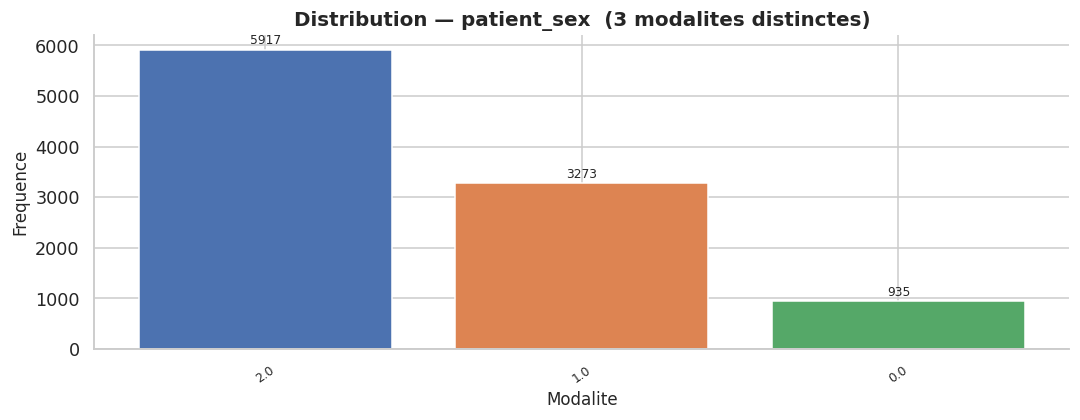

  patient_sex : 3 modalites | mode = '2.0' (58.0%)
  Aucune modalite rare detectee



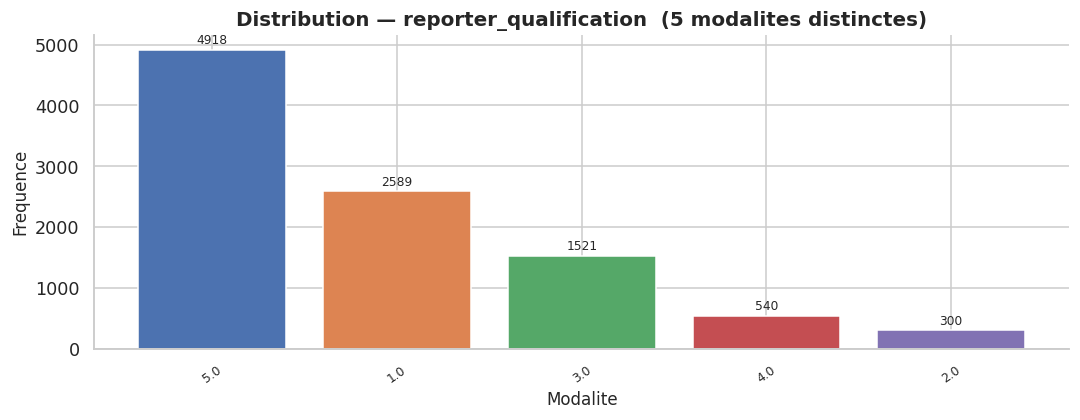

  reporter_qualification : 5 modalites | mode = '5.0' (48.2%)
  Aucune modalite rare detectee



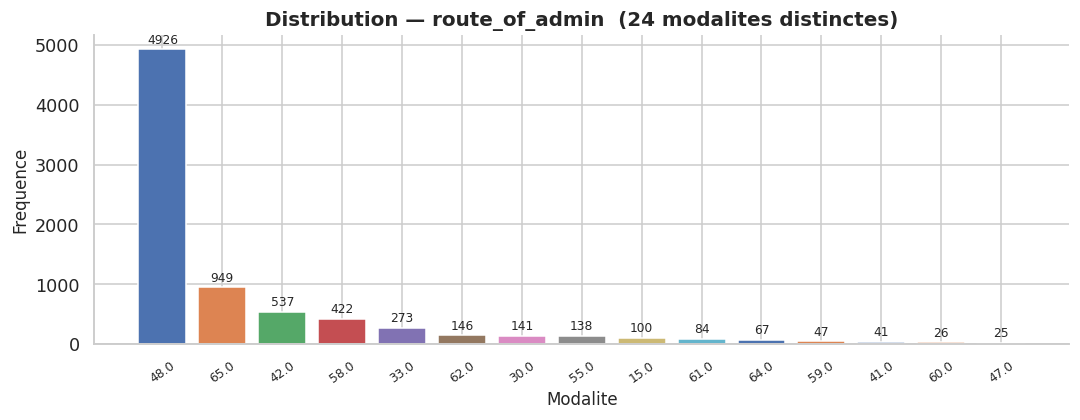

  route_of_admin : 24 modalites | mode = '48.0' (48.3%)
  Modalites rares (< 1%) : ['15.0', '61.0', '64.0', '59.0', '41.0', '60.0', '47.0', '67.0', '50.0', '45.0', '37.0', '2.0', '40.0', '31.0', '8.0', '49.0', '51.0', '4.0', '23.0', '14.0', '13.0', '43.0']  -> a regrouper en 'other' en Phase 2



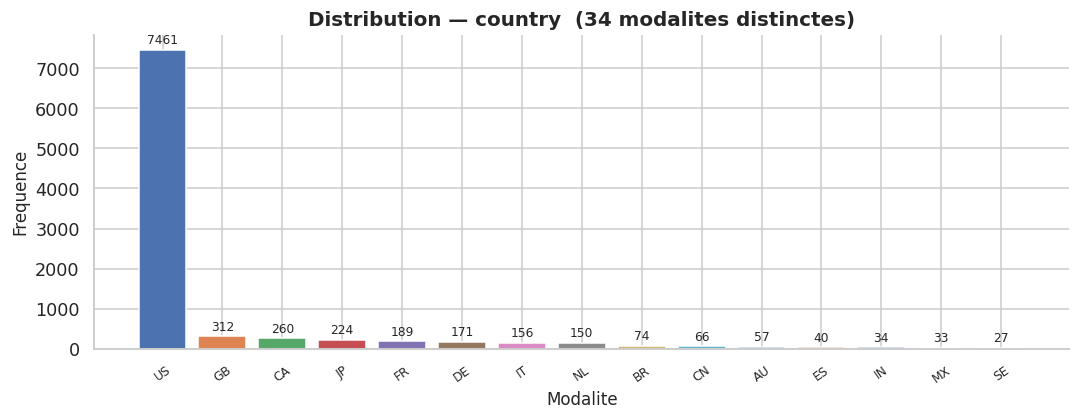

  country : 34 modalites | mode = 'US' (73.1%)
  Modalites rares (< 1%) : ['BR', 'CN', 'AU', 'ES', 'IN', 'MX', 'SE', 'TR', 'CO', 'IE', 'AR', 'BE', 'PL', 'IL', 'CH', 'KR', 'BD', 'PH', 'AT', 'CL', 'RU', 'ZA', 'PT', 'DK', 'PE', 'GR', 'TW', 'HR', 'PR', 'VE', 'HU', 'TH', 'FI', 'LB', 'CZ', 'NO', 'NZ', 'SK', 'MY', 'HK', 'EG', 'IR', 'RO', 'KE', 'ID', 'SA', 'TN', 'EC', 'BG', 'RS', 'LY', 'MA', 'UA', 'MW', 'VN', 'DZ', 'KP', 'GT', 'GW', 'UY', 'CR', 'SG', 'SI', 'LT', 'BW', 'UG', 'PA']  -> a regrouper en 'other' en Phase 2



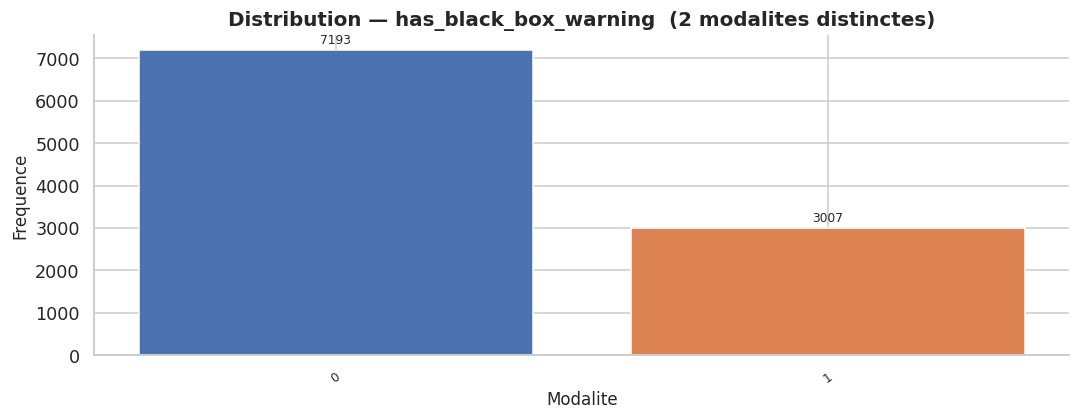

  Aucune modalite rare detectee



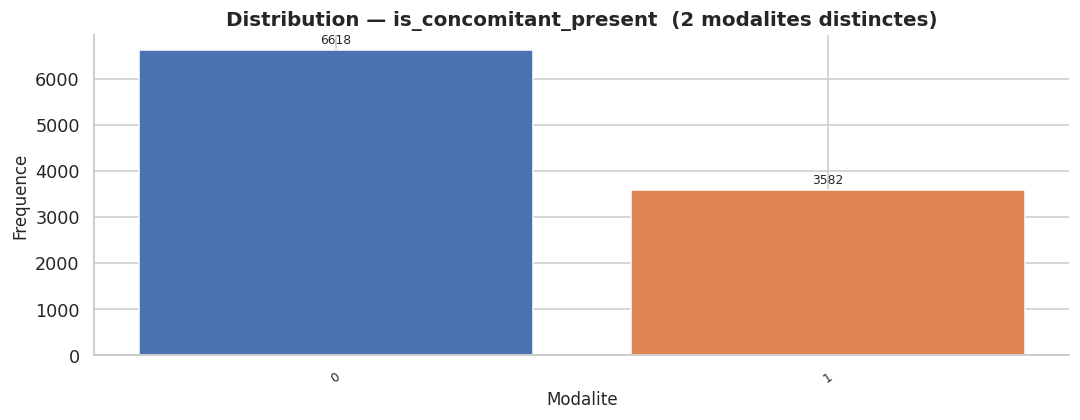

  is_concomitant_present : 2 modalites | mode = '0' (64.9%)
  Aucune modalite rare detectee



In [18]:
THRESHOLD_RARE = 0.01

for col in CATEGORICAL_COLS:
    vc     = df[col].astype(str).value_counts()
    vc_pct = vc / len(df) * 100
    rare   = vc_pct[vc_pct < THRESHOLD_RARE * 100]

    fig, ax = plt.subplots(figsize=(10, 4))
    top  = vc.head(15)
    bars = ax.bar(top.index.astype(str), top.values,
                  color=PALETTE_CAT[:len(top)], edgecolor="white")
    ax.bar_label(bars, fontsize=8, padding=2)
    ax.set_title(f"Distribution — {col}  ({vc.nunique()} modalites distinctes)")
    ax.set_xlabel("Modalite")
    ax.set_ylabel("Frequence")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    plt.tight_layout()
    plt.show()

    print(f"  {col} : {vc.nunique()} modalites | "
          f"mode = '{vc.index[0]}' ({vc_pct.iloc[0]:.1f}%)")
    if not rare.empty:
        print(f"  Modalites rares (< 1%) : {list(rare.index)}  -> a regrouper en 'other' en Phase 2")
    else:
        print(f"  Aucune modalite rare detectee")
    print()


---
## 3. Exploration bivariée

### 3a. Numérique x Cible — Boxplots par classe


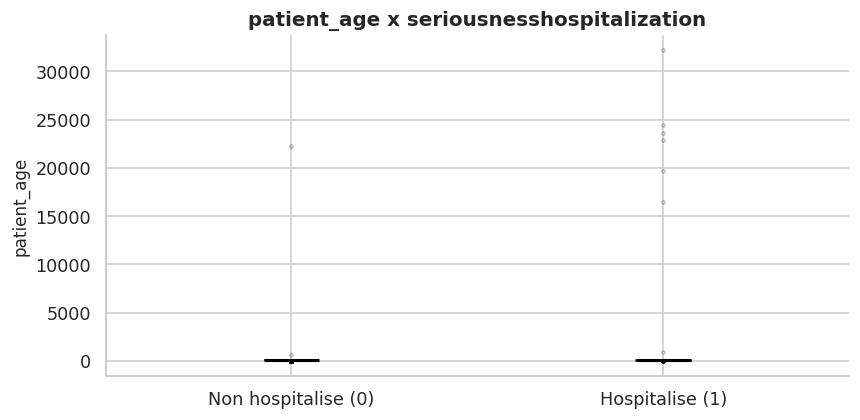

  patient_age | mediane classe 0 = 61.00 | mediane classe 1 = 60.00 | Mann-Whitney p = 0.2646 -> Non significatif



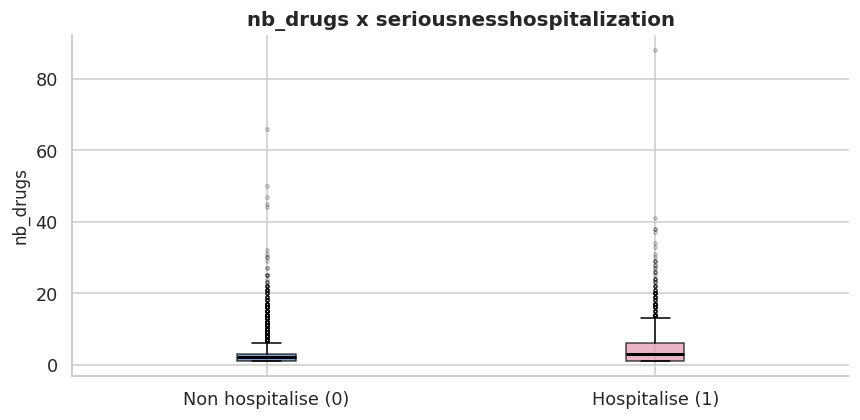

  nb_drugs | mediane classe 0 = 2.00 | mediane classe 1 = 3.00 | Mann-Whitney p = 0.0000 -> Significatif (p < 0.05)



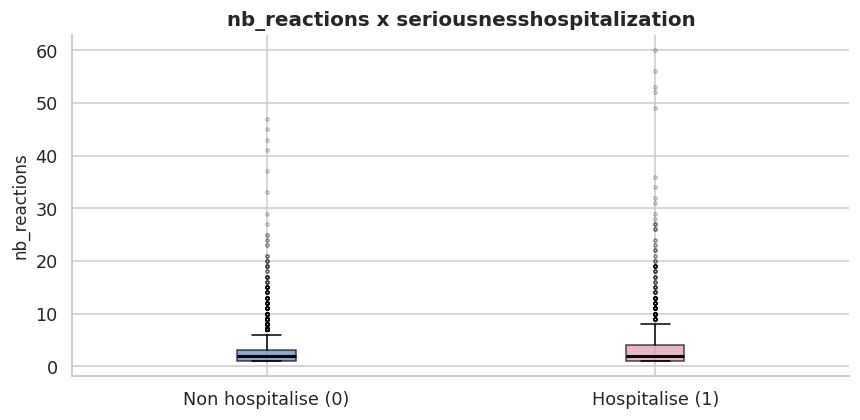

  nb_reactions | mediane classe 0 = 2.00 | mediane classe 1 = 2.00 | Mann-Whitney p = 0.0000 -> Significatif (p < 0.05)



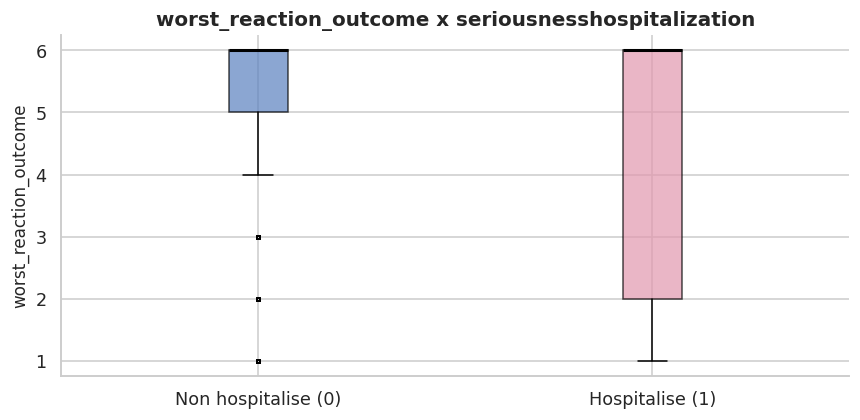

  worst_reaction_outcome | mediane classe 0 = 6.00 | mediane classe 1 = 6.00 | Mann-Whitney p = 0.0000 -> Significatif (p < 0.05)



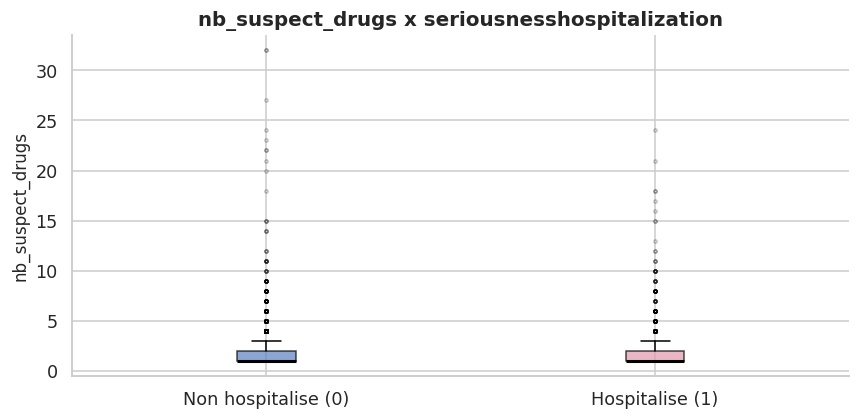

  nb_suspect_drugs | mediane classe 0 = 1.00 | mediane classe 1 = 1.00 | Mann-Whitney p = 0.0000 -> Significatif (p < 0.05)



In [19]:
for col in NUMERIC_COLS:
    data_0 = df[df[TARGET_COL] == 0][col].dropna()
    data_1 = df[df[TARGET_COL] == 1][col].dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(
        [data_0, data_1],
        labels=["Non hospitalise (0)", "Hospitalise (1)"],
        patch_artist=True,
        medianprops=dict(linewidth=2, color="black"),
        flierprops=dict(marker="o", markersize=2, alpha=0.25),
    )
    bp["boxes"][0].set_facecolor(PALETTE[0])
    bp["boxes"][1].set_facecolor(PALETTE[1])
    for box in bp["boxes"]:
        box.set_alpha(0.7)

    ax.set_title(f"{col} x seriousnesshospitalization")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

    stat, pval = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
    sig = "Significatif (p < 0.05)" if pval < 0.05 else "Non significatif"
    print(f"  {col} | mediane classe 0 = {data_0.median():.2f} | "
          f"mediane classe 1 = {data_1.median():.2f} | "
          f"Mann-Whitney p = {pval:.4f} -> {sig}")
    print()


### 3b. Catégorielle x Cible — Taux de classe positive par modalité

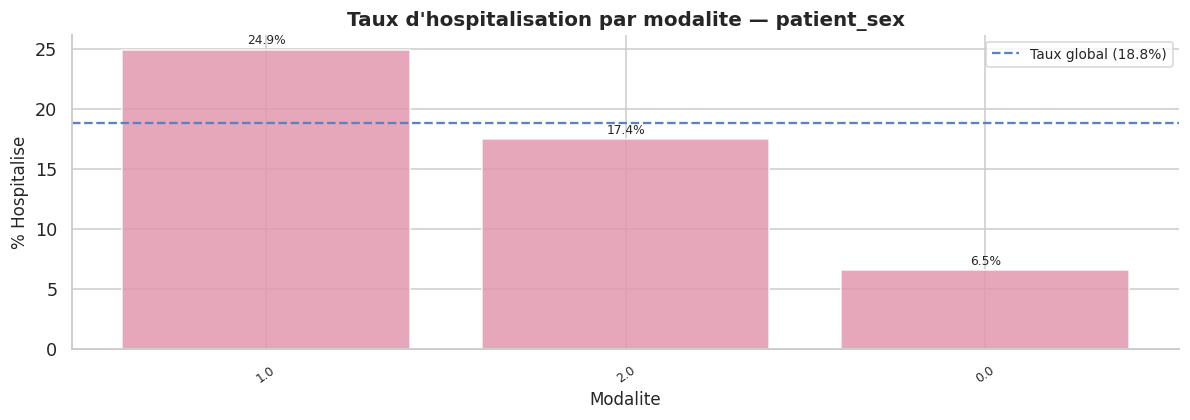

  patient_sex — tableau croise (top 10) :
             Non hospitalise (%)  Hospitalise (%)
patient_sex                                      
1.0                         75.1             24.9
2.0                         82.6             17.4
0.0                         93.5              6.5



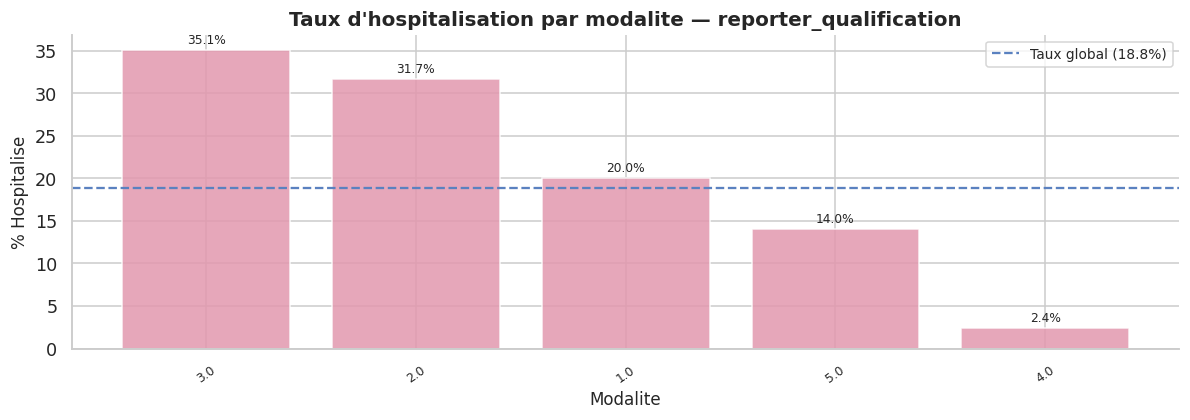

  reporter_qualification — tableau croise (top 10) :
                        Non hospitalise (%)  Hospitalise (%)
reporter_qualification                                      
3.0                                    64.9             35.1
2.0                                    68.3             31.7
1.0                                    80.0             20.0
5.0                                    86.0             14.0
4.0                                    97.6              2.4



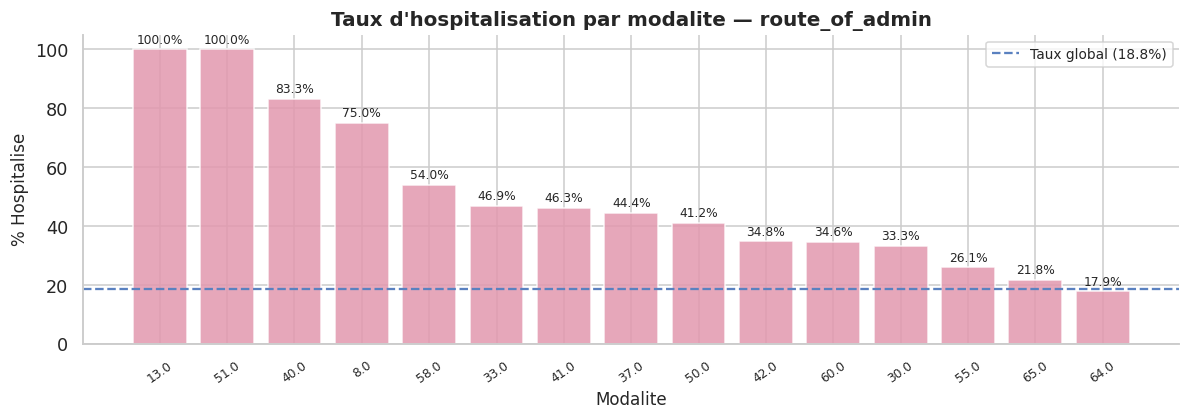

  route_of_admin — tableau croise (top 10) :
                Non hospitalise (%)  Hospitalise (%)
route_of_admin                                      
13.0                            0.0            100.0
51.0                            0.0            100.0
40.0                           16.7             83.3
8.0                            25.0             75.0
58.0                           46.0             54.0
33.0                           53.1             46.9
41.0                           53.7             46.3
37.0                           55.6             44.4
50.0                           58.8             41.2
42.0                           65.2             34.8



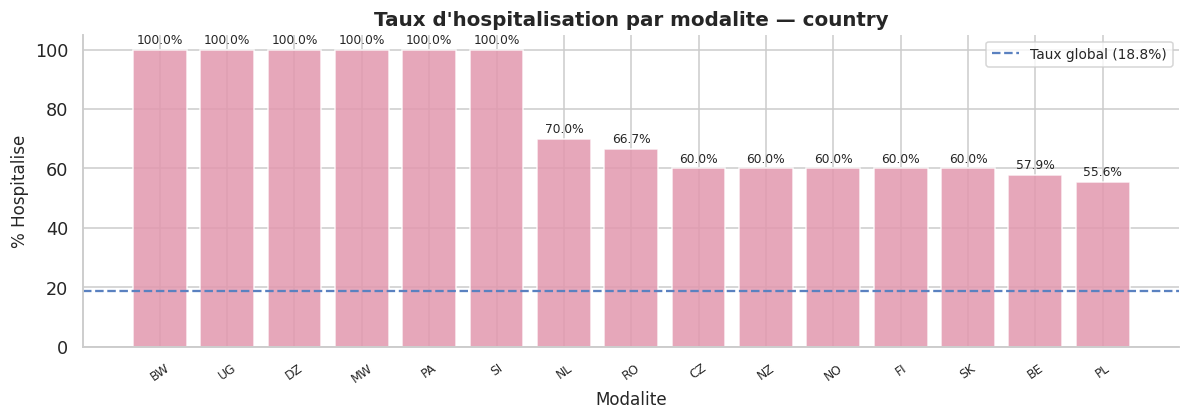

  country — tableau croise (top 10) :
         Non hospitalise (%)  Hospitalise (%)
country                                      
BW                       0.0            100.0
UG                       0.0            100.0
DZ                       0.0            100.0
MW                       0.0            100.0
PA                       0.0            100.0
SI                       0.0            100.0
NL                      30.0             70.0
RO                      33.3             66.7
CZ                      40.0             60.0
NZ                      40.0             60.0



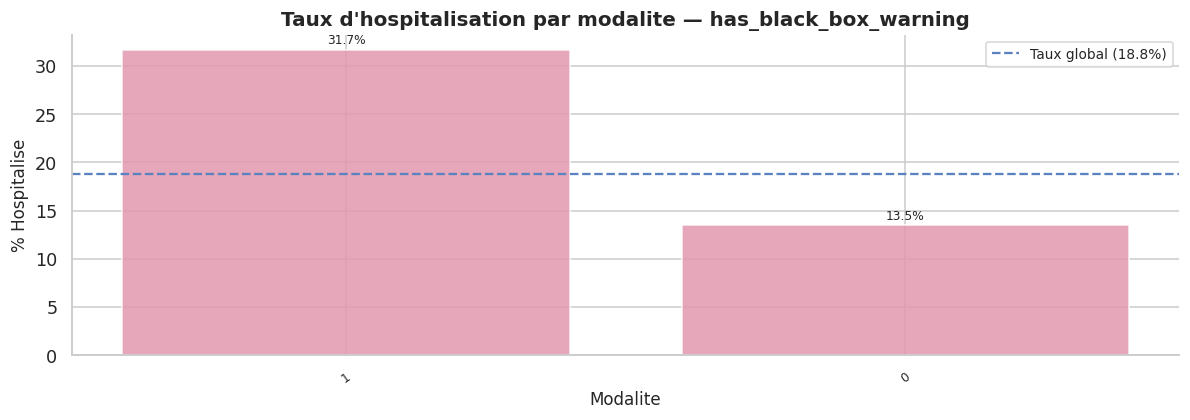

  has_black_box_warning — tableau croise (top 10) :
                       Non hospitalise (%)  Hospitalise (%)
has_black_box_warning                                      
1                                     68.3             31.7
0                                     86.5             13.5



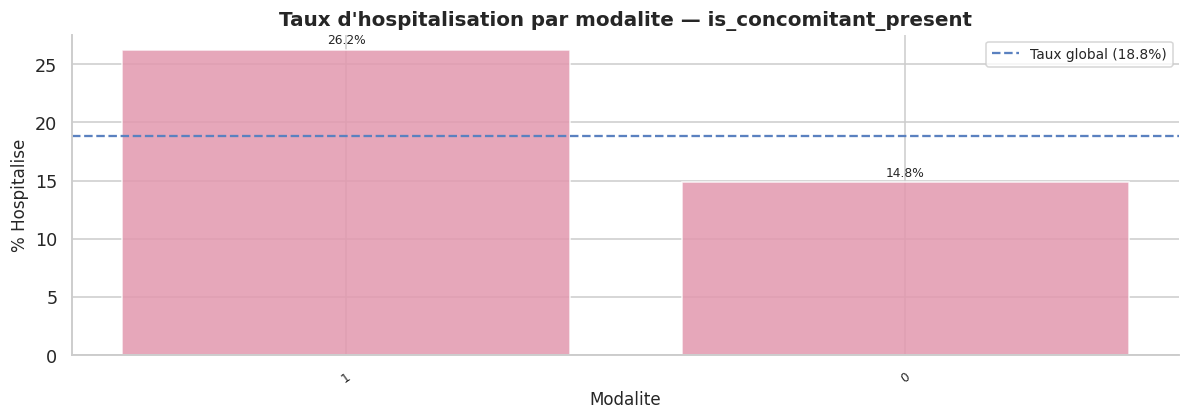

  is_concomitant_present — tableau croise (top 10) :
                        Non hospitalise (%)  Hospitalise (%)
is_concomitant_present                                      
1                                      73.8             26.2
0                                      85.2             14.8



In [20]:
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(df[col].astype(str), df[TARGET_COL],
                     normalize="index") * 100
    ct.columns = ["Non hospitalise (%)", "Hospitalise (%)"]
    ct = ct.sort_values("Hospitalise (%)", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(11, 4))
    bars = ax.bar(ct.index, ct["Hospitalise (%)"],
                  color=PALETTE[1], edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
    ax.axhline(df[TARGET_COL].mean() * 100, color=PALETTE[0],
               linestyle="--", linewidth=1.5,
               label=f"Taux global ({df[TARGET_COL].mean()*100:.1f}%)")
    ax.set_title(f"Taux d'hospitalisation par modalite — {col}")
    ax.set_xlabel("Modalite")
    ax.set_ylabel("% Hospitalise")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    plt.tight_layout()
    plt.show()

    print(f"  {col} — tableau croise (top 10) :")
    print(ct.head(10).round(1).to_string())
    print()


### 3c. Numérique x Numérique — Matrice de corrélation

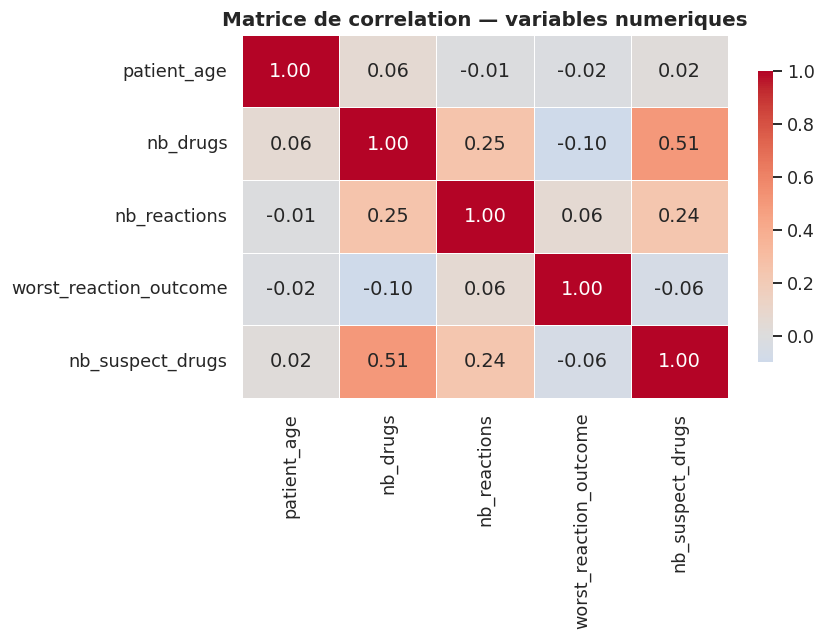

Paires fortement correlees (|r| > 0.7) :
  Aucune paire fortement correlee detectee (seuil |r| > 0.7)


In [21]:
corr_matrix = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Matrice de correlation — variables numeriques")
plt.tight_layout()
plt.show()

print("Paires fortement correlees (|r| > 0.7) :")
found = False
for i in range(len(NUMERIC_COLS)):
    for j in range(i+1, len(NUMERIC_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {NUMERIC_COLS[i]} x {NUMERIC_COLS[j]} : r = {r:.3f}")
            found = True
if not found:
    print("  Aucune paire fortement correlee detectee (seuil |r| > 0.7)")


---
## 4. Analyse spécifique du déséquilibre

### 4a. Ratio exact des classes


In [22]:
counts = df[TARGET_COL].value_counts().sort_index()
ratios = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

print("── Ratio exact des classes ───────────────────────────────")
print(f"  Classe 0 (non hospitalise) : {counts[0]:>6}  ({ratios[0]:.2f}%)")
print(f"  Classe 1 (hospitalise)     : {counts[1]:>6}  ({ratios[1]:.2f}%)")
print(f"  Total                      : {len(df):>6}")
print()
print(f"  Ratio desequilibre : 1 cas positif pour {counts[0]/counts[1]:.0f} negatifs")
constraint_ok = 0.05 <= ratios[1]/100 <= 0.25
print(f"  Contrainte 5%-25%  : {'Respectee' if constraint_ok else 'Non respectee'}")


── Ratio exact des classes ───────────────────────────────
  Classe 0 (non hospitalise) :   8279  (81.17%)
  Classe 1 (hospitalise)     :   1921  (18.83%)
  Total                      :  10200

  Ratio desequilibre : 1 cas positif pour 4 negatifs
  Contrainte 5%-25%  : Respectee


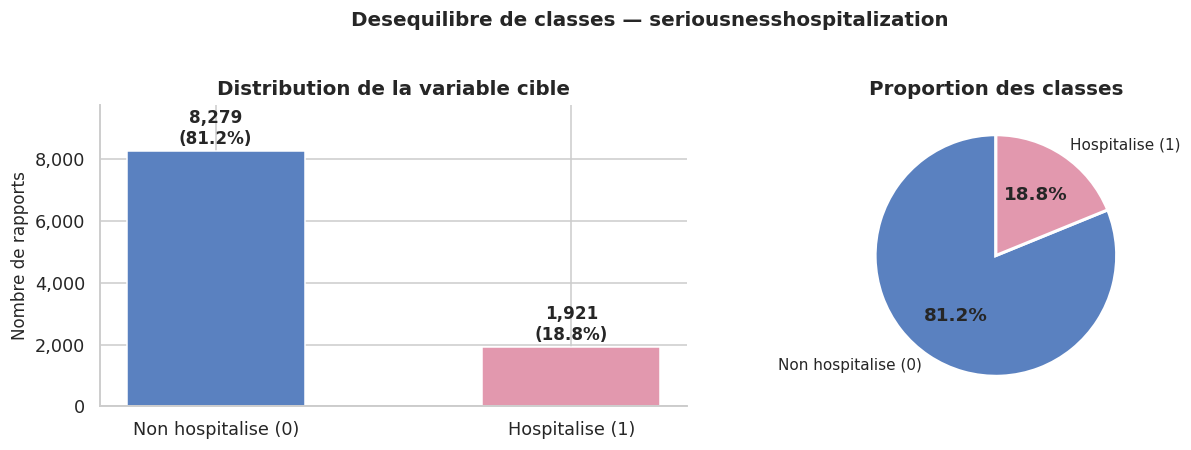

In [23]:
labels = ["Non hospitalise (0)", "Hospitalise (1)"]
values = [counts[0], counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(labels, values, color=PALETTE, edgecolor="white", width=0.5)
for bar, val, ratio in zip(bars, values, [ratios[0], ratios[1]]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.012,
        f"{val:,}\n({ratio:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de rapports")
ax.set_ylim(0, max(values) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=PALETTE, autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(12)
ax2.set_title("Proportion des classes")

plt.suptitle("Desequilibre de classes — seriousnesshospitalization",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 4b. Statistiques descriptives séparées par classe

In [24]:
stats_0 = df[df[TARGET_COL] == 0][NUMERIC_COLS].describe().round(2)
stats_1 = df[df[TARGET_COL] == 1][NUMERIC_COLS].describe().round(2)

print("── Classe 0 — Non hospitalise ────────────────────────────")
print(stats_0.to_string())
print()
print("── Classe 1 — Hospitalise ────────────────────────────────")
print(stats_1.to_string())


── Classe 0 — Non hospitalise ────────────────────────────
       patient_age  nb_drugs  nb_reactions  worst_reaction_outcome  nb_suspect_drugs
count      5247.00   8279.00       8279.00                 7834.00           8279.00
mean         62.01      2.88          2.40                    5.06              1.65
std         306.93      3.30          2.53                    1.65              1.44
min           0.00      1.00          1.00                    1.00              1.00
25%          47.00      1.00          1.00                    5.00              1.00
50%          61.00      2.00          2.00                    6.00              1.00
75%          72.00      3.00          3.00                    6.00              2.00
max       22240.00     66.00         47.00                    6.00             32.00

── Classe 1 — Hospitalise ────────────────────────────────
       patient_age  nb_drugs  nb_reactions  worst_reaction_outcome  nb_suspect_drugs
count      1528.00   1921.00   

In [25]:
diff = pd.DataFrame({
    "Moyenne classe 0": df[df[TARGET_COL]==0][NUMERIC_COLS].mean().round(3),
    "Moyenne classe 1": df[df[TARGET_COL]==1][NUMERIC_COLS].mean().round(3),
})
diff["Difference absolue"]     = (diff["Moyenne classe 1"] - diff["Moyenne classe 0"]).round(3)
diff["Difference relative (%)"] = (
    (diff["Moyenne classe 1"] - diff["Moyenne classe 0"])
    / diff["Moyenne classe 0"].replace(0, np.nan) * 100
).round(1)
diff = diff.sort_values("Difference relative (%)", ascending=False, key=abs)
diff


,Moyenne classe 0,Moyenne classe 1,Difference absolue,Difference relative (%)
patient_age,62.014,147.927,85.913,138.5
nb_drugs,2.878,4.733,1.855,64.5
nb_reactions,2.404,3.844,1.440,59.9
nb_suspect_drugs,1.650,2.028,0.378,22.9
worst_reaction_outcome,5.059,4.241,-0.818,-16.2


### 4c. Identification des features signaux

In [26]:
signal_features = []

print("── Features signaux — variables numeriques (test Mann-Whitney) ──")
print()
for col in NUMERIC_COLS:
    g0 = df[df[TARGET_COL]==0][col].dropna()
    g1 = df[df[TARGET_COL]==1][col].dropna()
    stat_mw, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    delta = abs(g1.median() - g0.median())
    is_signal = pval < 0.05
    label = "SIGNAL" if is_signal else "faible"
    if is_signal:
        signal_features.append(col)
    print(f"  [{label:<6}]  {col:<30} "
          f"med0={g0.median():.2f}  med1={g1.median():.2f}  "
          f"delta={delta:.2f}  p={pval:.4f}")

print()
print("── Features signaux — variables categorielles (test Chi2) ──")
print()
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(df[col].astype(str), df[TARGET_COL])
    if ct.shape[0] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ct)
    is_signal = pval < 0.05
    label = "SIGNAL" if is_signal else "faible"
    if is_signal:
        signal_features.append(col)
    print(f"  [{label:<6}]  {col:<30} chi2={chi2:.2f}  p={pval:.4f}")

print()
print(f"Total features signaux identifies : {len(signal_features)}")
for f in signal_features:
    print(f"  -> {f}")


── Features signaux — variables numeriques (test Mann-Whitney) ──

  [faible]  patient_age                    med0=61.00  med1=60.00  delta=1.00  p=0.2646
  [SIGNAL]  nb_drugs                       med0=2.00  med1=3.00  delta=1.00  p=0.0000
  [SIGNAL]  nb_reactions                   med0=2.00  med1=2.00  delta=0.00  p=0.0000
  [SIGNAL]  worst_reaction_outcome         med0=6.00  med1=6.00  delta=0.00  p=0.0000
  [SIGNAL]  nb_suspect_drugs               med0=1.00  med1=1.00  delta=0.00  p=0.0000

── Features signaux — variables categorielles (test Chi2) ──

  [SIGNAL]  patient_sex                    chi2=178.92  p=0.0000
  [SIGNAL]  reporter_qualification         chi2=469.32  p=0.0000
  [SIGNAL]  route_of_admin                 chi2=734.95  p=0.0000
  [SIGNAL]  country                        chi2=1053.78  p=0.0000
  [SIGNAL]  has_black_box_warning          chi2=457.70  p=0.0000
  [SIGNAL]  is_concomitant_present         chi2=196.01  p=0.0000

Total features signaux identifies : 10
  -> nb

### 4d. Visualisation du pouvoir prédictif — p-values par variable

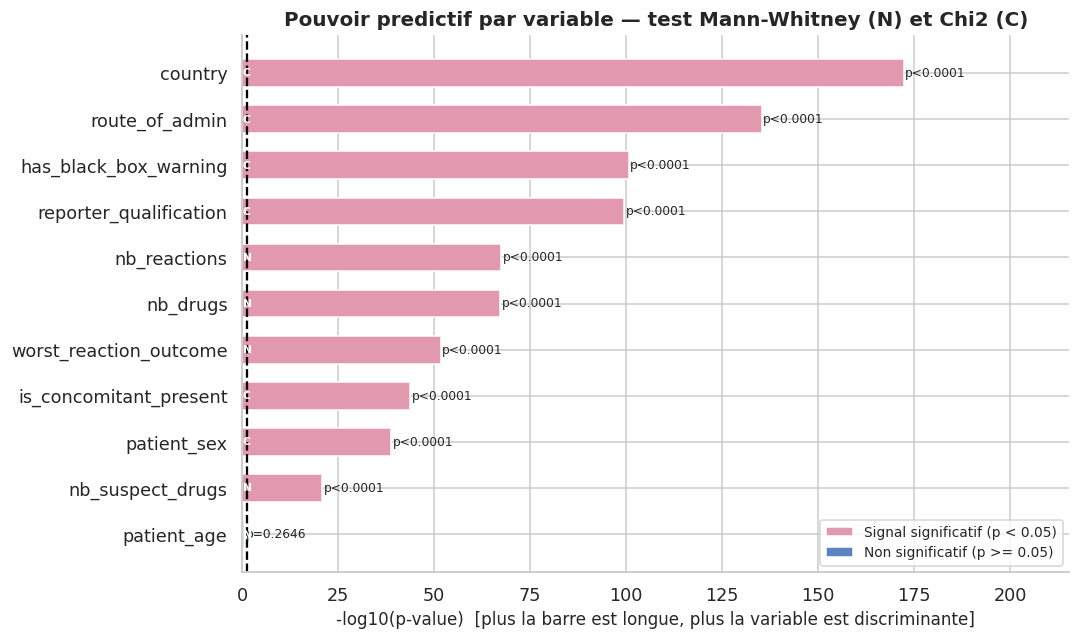

Lecture du graphique :
  - Chaque barre = une variable du dataset
  - Longueur = -log10(p-value) : plus longue = plus discriminante
  - N = variable numerique (test Mann-Whitney)
  - C = variable categorielle (test Chi2)
  - Ligne pointillee = seuil de significativite p=0.05


In [27]:
# Recalcul des p-values pour toutes les variables
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency

pvalue_data = []

for col in NUMERIC_COLS:
    g0 = df[df[TARGET_COL] == 0][col].dropna()
    g1 = df[df[TARGET_COL] == 1][col].dropna()
    _, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    pvalue_data.append({
        "variable": col,
        "type": "numerique",
        "pvalue": pval,
        "neg_log10_p": -np.log10(max(pval, 1e-300)),
        "is_signal": pval < 0.05,
    })

for col in CATEGORICAL_COLS:
    ct = pd.crosstab(df[col].astype(str), df[TARGET_COL])
    if ct.shape[0] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ct)
    pvalue_data.append({
        "variable": col,
        "type": "categorielle",
        "pvalue": pval,
        "neg_log10_p": -np.log10(max(pval, 1e-300)),
        "is_signal": pval < 0.05,
    })

pv_df = pd.DataFrame(pvalue_data).sort_values("neg_log10_p", ascending=True)

# Colors: signal = orange, non-signal = blue
colors = [PALETTE[1] if s else PALETTE[0] for s in pv_df["is_signal"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(pv_df["variable"], pv_df["neg_log10_p"],
               color=colors, edgecolor="white", height=0.6)

# Threshold line at p=0.05 -> -log10(0.05) = 1.30
threshold = -np.log10(0.05)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Seuil p=0.05  (-log10 = {threshold:.2f})")

# Labels on bars
for bar, row in zip(bars, pv_df.itertuples()):
    label = f"p={row.pvalue:.4f}" if row.pvalue >= 0.0001 else "p<0.0001"
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=8)

# Type annotation (N = numerique, C = categorielle)
for bar, row in zip(bars, pv_df.itertuples()):
    tag = "N" if row.type == "numerique" else "C"
    ax.text(0.15, bar.get_y() + bar.get_height()/2,
            tag, va="center", fontsize=7, color="white", fontweight="bold")

ax.set_xlabel("-log10(p-value)  [plus la barre est longue, plus la variable est discriminante]")
ax.set_title("Pouvoir predictif par variable — test Mann-Whitney (N) et Chi2 (C)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, pv_df["neg_log10_p"].max() * 1.25)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[1], label="Signal significatif (p < 0.05)"),
    Patch(facecolor=PALETTE[0], label="Non significatif (p >= 0.05)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

print("Lecture du graphique :")
print("  - Chaque barre = une variable du dataset")
print("  - Longueur = -log10(p-value) : plus longue = plus discriminante")
print("  - N = variable numerique (test Mann-Whitney)")
print("  - C = variable categorielle (test Chi2)")
print("  - Ligne pointillee = seuil de significativite p=0.05")


---
## 5. Synthèse de l'analyse exploratoire


In [28]:
minority_pct = df[TARGET_COL].mean() * 100

# ── Calcul automatique des problemes qualite
quality_issues = []
for col in NUMERIC_COLS:
    miss_pct = df[col].isna().mean() * 100
    if miss_pct > 0:
        quality_issues.append((col, f"{miss_pct:.1f}% valeurs manquantes"))
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    if n_out > 0:
        quality_issues.append((col, f"{n_out} outliers IQR ({n_out/len(df)*100:.1f}%)"))

for col in CATEGORICAL_COLS:
    miss_pct = df[col].isna().mean() * 100
    if miss_pct > 0:
        quality_issues.append((col, f"{miss_pct:.1f}% valeurs manquantes"))
    vc_pct = df[col].astype(str).value_counts(normalize=True) * 100
    rare   = vc_pct[vc_pct < 1.0]
    if not rare.empty:
        quality_issues.append((col, f"{len(rare)} modalites rares < 1%"))

# ── Correlations fortes
strong_corr = []
for i in range(len(NUMERIC_COLS)):
    for j in range(i+1, len(NUMERIC_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            strong_corr.append((NUMERIC_COLS[i], NUMERIC_COLS[j], r))

print("=" * 65)
print("  SYNTHESE DE L'ANALYSE EXPLORATOIRE")
print("=" * 65)
print()
print("1. DESEQUILIBRE DES CLASSES")
print(f"   Classe majoritaire (non hospitalise) : {100-minority_pct:.1f}%")
print(f"   Classe minoritaire (hospitalise)     : {minority_pct:.1f}%")
print(f"   Le dataset presente un desequilibre naturel confirme.")
print(f"   Une strategie de gestion (SMOTE, class_weight) sera necessaire en Phase 3.")
print()
print("2. VARIABLES POTENTIELLEMENT PREDICTIVES (features signaux)")
if signal_features:
    for f in signal_features:
        print(f"   - {f}")
else:
    print("   Aucune feature signal significative detectee.")
print()
print("3. CORRELATIONS ENTRE VARIABLES NUMERIQUES")
if strong_corr:
    for a, b, r in strong_corr:
        print(f"   - {a} x {b} : r = {r:.3f}  (risque de multicollinearite)")
else:
    print("   Aucune correlation forte detectee (|r| > 0.7).")
    print("   Les variables numeriques sont suffisamment independantes.")
print()
print("4. PROBLEMES DE QUALITE DETECTES")
if quality_issues:
    for col, issue in quality_issues:
        print(f"   - {col:<30} {issue}")
else:
    print("   Aucun probleme majeur detecte.")
print()
print("5. OBSERVATIONS CLES")
print("   - La variable worst_reaction_outcome est dominee par la valeur 6 (unknown).")
print("   - La variable country presente une forte concentration sur US (~74%).")
print("   - La variable has_black_box_warning necessite une verification du matching API.")
print("   - Les variables nb_drugs et nb_reactions presentent des outliers importants.")
print()
print("=" * 65)


  SYNTHESE DE L'ANALYSE EXPLORATOIRE

1. DESEQUILIBRE DES CLASSES
   Classe majoritaire (non hospitalise) : 81.2%
   Classe minoritaire (hospitalise)     : 18.8%
   Le dataset presente un desequilibre naturel confirme.
   Une strategie de gestion (SMOTE, class_weight) sera necessaire en Phase 3.

2. VARIABLES POTENTIELLEMENT PREDICTIVES (features signaux)
   - nb_drugs
   - nb_reactions
   - worst_reaction_outcome
   - nb_suspect_drugs
   - patient_sex
   - reporter_qualification
   - route_of_admin
   - country
   - has_black_box_warning
   - is_concomitant_present

3. CORRELATIONS ENTRE VARIABLES NUMERIQUES
   Aucune correlation forte detectee (|r| > 0.7).
   Les variables numeriques sont suffisamment independantes.

4. PROBLEMES DE QUALITE DETECTES
   - patient_age                    33.6% valeurs manquantes
   - patient_age                    205 outliers IQR (2.0%)
   - nb_drugs                       798 outliers IQR (7.8%)
   - nb_reactions                   705 outliers IQR (6.9